# Caracterização Estrutural do Google Web Graph
## Análise de Escala Livre em Redes Reais — SNAP Dataset

### Grupo

Anselmo Teixeira - 2410414  
João Marcelo Jucá - 2410392  
Thiago Victor Ferreira - 2410413

---

**Disciplina:** Resolução de Problemas em Grafos  
**Dataset:** [web-Google](https://snap.stanford.edu/data/web-Google.html) — Stanford Network Analysis Project (SNAP)  
**Tipo de rede:** Grafo dirigido de páginas web  
**Fonte original:** Google Programming Contest, 2002

---
## Parte 0 — Instalação de dependências


In [1]:
!pip install matplotlib numpy scipy powerlaw --quiet

---
## Parte 1 — Implementação das estruturas (Algs 4)

Implementamos `Node`, `LinkIterator`, `Bag` e `Digraph`

### Node e LinkIterator — `algs4/utils/linklist.py`
- `Node`: nó da lista encadeada com `item` e ponteiro `next`
- `LinkIterator`: percorre a lista do `first` até `None`

### Bag — `algs4/bag.py`
Lista encadeada onde a inserção é sempre no início: **O(1)**.

### Digraph — `algs4/digraph.py`
Grafo dirigido com dicionário de Bags (`adj`).  
O in-degree é calculado via `reverse()` — novo Digraph com arestas invertidas.

In [2]:
# ============================================================
# NODE e LINKITERATOR
# ============================================================
class Node:
    def __init__(self, item, next_node):
        self.item = item
        self.next = next_node

class LinkIterator:
    def __init__(self, current):
        self.current = current
    def __iter__(self):
        return self
    def __next__(self):
        if self.current is None:
            raise StopIteration()
        else:
            item = self.current.item
            self.current = self.current.next
            return item


# ============================================================
# BAG
# ============================================================
class Bag:
    def __init__(self):
        self.first = None
        self.n = 0

    def __str__(self):
        return " ".join(str(i) for i in self)

    def __iter__(self):
        return LinkIterator(self.first)

    def __len__(self):
        return self.n

    def size(self):
        return self.n

    def is_empty(self):
        return self.first is None

    def add(self, item):
        """Insere item no início da lista encadeada — O(1)."""
        oldfirst = self.first
        self.first = Node(item, oldfirst)
        self.n += 1


# ============================================================
# DIGRAPH
# ============================================================
class Digraph:
    def __init__(self, v=0):
        self.V = v
        self.E = 0
        self.adj = {}
        for v in range(self.V):
            self.adj[v] = Bag()

    def __str__(self):
        s = "%d vertices, %d edges\n" % (self.V, self.E)
        s += "\n".join("%d: %s" % (v, " ".join(str(w) for w in self.adj[v]))
                       for v in range(self.V))
        return s

    def add_edge(self, v, w):
        """Adiciona aresta v → w — O(1)."""
        v, w = int(v), int(w)
        self.adj[v].add(w)
        self.E += 1

    def degree(self, v):
        """Out-degree do vértice v — O(1)."""
        return len(self.adj[v])

    def max_degree(self):
        """Maior out-degree do grafo — O(V)."""
        max_deg = 0
        for v in range(self.V):
            max_deg = max(max_deg, self.degree(v))
        return max_deg

    def number_of_self_loops(self):
        """Conta auto-loops — O(V+E)."""
        count = 0
        for v in range(self.V):
            for w in self.adj[v]:
                if w == v:
                    count += 1
        return count

    def reverse(self):
        """
        Retorna novo Digraph com todas as arestas invertidas.
        in_degree(v) = G.reverse().degree(v)
        Complexidade: O(V+E).
        """
        R = Digraph(self.V)
        v = 0
        while v < self.V:
            for w in self.adj[v]:
                R.add_edge(w, v)
            v += 1
        return R

---
## Parte 2 — Carregamento do dataset

### Decisões de modelagem

| Decisão | Escolha | Justificativa |
|---|---|---|
| Tipo de grafo | **Dirigido** (Digraph) | Hiperlinks têm direção: página A → página B |
| Ponderação | **Não ponderado** | O dataset não fornece peso para as arestas |
| Temporal | **Não temporal** | Snapshot estático de 2002 |
| Auto-loops | **Removidos na leitura** | Verificação `u != v` antes de `add_edge` |
| Multi-arestas | **Removidas na leitura** | Conjunto `arestas_vistas` antes de `add_edge` |
| IDs dos nós | **Remapeados para 0..V-1** | `Digraph(V)` usa índices inteiros sequenciais |

### Por que remapear os IDs?

O `Digraph(V)` cria `adj[0], adj[1], ..., adj[V-1]`.  
Os IDs do SNAP são arbitrários e não sequenciais (ex: `0, 11, 4847...`).  
Fazemos dois passos: coletamos todos os IDs únicos, depois remapeamos para `0..V-1`.

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import powerlaw
import random
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3
})

ARQUIVO_TXT = 'web-Google.txt'

if not os.path.exists(ARQUIVO_TXT):
    print(f"Arquivo '{ARQUIVO_TXT}' nao encontrado.")
else:
    # PASSO 1: coleta IDs unicos
    print('Passo 1: lendo IDs unicos...')
    ids_unicos     = set()
    arestas_brutas = []

    with open(ARQUIVO_TXT, 'r') as f:
        for linha in f:
            if linha.startswith('#') or not linha.strip():
                continue
            partes = linha.strip().split()
            if len(partes) >= 2:
                try:
                    u, v = int(partes[0]), int(partes[1])
                    if u != v:  # remove auto-loops
                        ids_unicos.add(u)
                        ids_unicos.add(v)
                        arestas_brutas.append((u, v))
                except ValueError:
                    continue

    # PASSO 2: remapeia IDs para 0..V-1
    print('Passo 2: remapeando IDs para 0..V-1...')
    id_para_idx = {node_id: idx for idx, node_id in enumerate(sorted(ids_unicos))}
    V_total = len(ids_unicos)

    # PASSO 3: cria Digraph(V) e insere arestas
    print(f'Passo 3: criando Digraph({V_total:,})...')
    G = Digraph(V_total)

    arestas_vistas = set()  # remove multi-arestas
    for (u, v) in arestas_brutas:
        idx_u = id_para_idx[u]
        idx_v = id_para_idx[v]
        if (idx_u, idx_v) not in arestas_vistas:
            G.add_edge(idx_u, idx_v)
            arestas_vistas.add((idx_u, idx_v))

    print(f'\nDigraph (Algs 4) carregado!')
    print(f'   {G.V} vertices, {G.E} edges')
    print(f'   Auto-loops confirmados: {G.number_of_self_loops()}')

Passo 1: lendo IDs unicos...
Passo 2: remapeando IDs para 0..V-1...
Passo 3: criando Digraph(875,713)...

Digraph (Algs 4) carregado!
   875713 vertices, 5105039 edges
   Auto-loops confirmados: 0


---
## Parte 3 — Definição formal do grafo

$$G = (V, E)$$

- $V$ — conjunto de páginas web
- $E \subseteq V \times V$ — conjunto de hiperlinks dirigidos
- $(u, v) \in E$ — página $u$ contém um link para $v$

| Propriedade | Valor |
|---|---|
| Dirigido | Sim |
| Ponderado | Não |
| Simples | Sim — sem auto-loops ou multi-arestas |
| Estrutura | `Digraph` com `Bag` (lista encadeada) — Algs 4 |

---
## Parte 4 — Métricas estruturais básicas

- **out-degree(v)** = `G.degree(v)` — tamanho da Bag `adj[v]`, O(1)
- **in-degree(v)** = `G_rev.degree(v)` — out-degree de v no grafo reverso, O(1)

In [4]:
print('Calculando grafo reverso para in-degrees...')
G_rev = G.reverse()

out_degrees = [G.degree(v)     for v in range(G.V)]
in_degrees  = [G_rev.degree(v) for v in range(G.V)]

V = G.V
E = G.E
densidade      = E / (V * (V - 1))
grau_medio_out = np.mean(out_degrees)
grau_medio_in  = np.mean(in_degrees)

print('='*55)
print('      METRICAS ESTRUTURAIS — GOOGLE WEB GRAPH')
print('='*55)
print(f'  Ordem       |V|          : {V:>15,}')
print(f'  Tamanho     |E|          : {E:>15,}')
print(f'  Densidade               : {densidade:>15.8f}')
print(f'  Grau medio de saida     : {grau_medio_out:>15.4f}')
print(f'  Grau medio de entrada   : {grau_medio_in:>15.4f}')
print(f'  Grau max. de saida      : {max(out_degrees):>15,}')
print(f'  Grau max. de entrada    : {max(in_degrees):>15,}')
print('='*55)
print()
print('Interpretacao:')
print(f'   Densidade = {densidade:.2e} — rede MUITO esparsa')
print(f'   Bag (lista adjacencia) usa O(V+E) de memoria')
print(f'   Matriz usaria O(V2) = {V**2:.2e} celulas — inviavel')
print(f'   Grau max entrada = {max(in_degrees):,} — hubs confirmados')

Calculando grafo reverso para in-degrees...
      METRICAS ESTRUTURAIS — GOOGLE WEB GRAPH
  Ordem       |V|          :         875,713
  Tamanho     |E|          :       5,105,039
  Densidade               :      0.00000666
  Grau medio de saida     :          5.8296
  Grau medio de entrada   :          5.8296
  Grau max. de saida      :             456
  Grau max. de entrada    :           6,326

Interpretacao:
   Densidade = 6.66e-06 — rede MUITO esparsa
   Bag (lista adjacencia) usa O(V+E) de memoria
   Matriz usaria O(V2) = 7.67e+11 celulas — inviavel
   Grau max entrada = 6,326 — hubs confirmados


---
## Parte 5 — Coeficiente de Clustering

Clustering dirigido (Fagiolo, 2007) usando `G.adj[v]` e `G_rev.adj[v]`.

> Amostra de 3.000 nós — o cálculo exato para 875k nós levaria horas.

In [5]:
random.seed(42)
TAMANHO_AMOSTRA = 3_000
nos_amostrados  = random.sample(range(G.V), TAMANHO_AMOSTRA)

def clustering_dirigido(G, G_rev, v):
    """
    Clustering dirigido — Fagiolo (2007).
    Usa G.adj[v] (out-edges) e G_rev.adj[v] (in-edges) do Digraph.
    """
    out_v = set(G.adj[v])
    in_v  = set(G_rev.adj[v])
    todos = out_v | in_v

    d_tot = len(out_v) + len(in_v)
    d_bil = len(out_v & in_v)
    denom = d_tot * (d_tot - 1) - 2 * d_bil
    if denom == 0:
        return 0.0

    triangulos = 0
    lista = list(todos)
    for u in lista:
        out_u = set(G.adj[u])
        for w in lista:
            if u != w and w in out_u:
                triangulos += 1
    return triangulos / denom

print(f'Calculando clustering em {TAMANHO_AMOSTRA:,} nos...')
valores = [clustering_dirigido(G, G_rev, v) for v in nos_amostrados]
clustering_medio = np.mean(valores)

print(f'\nClustering medio dirigido: {clustering_medio:.6f}')
print(f'   Moderado-alto — reflexo do agrupamento tematico da web.')
print(f'   Redes BA puras teriam clustering proximo de 0.')

Calculando clustering em 3,000 nos...

Clustering medio dirigido: 0.272519
   Moderado-alto — reflexo do agrupamento tematico da web.
   Redes BA puras teriam clustering proximo de 0.


---
## Parte 6 — Distribuição de Graus P(k)

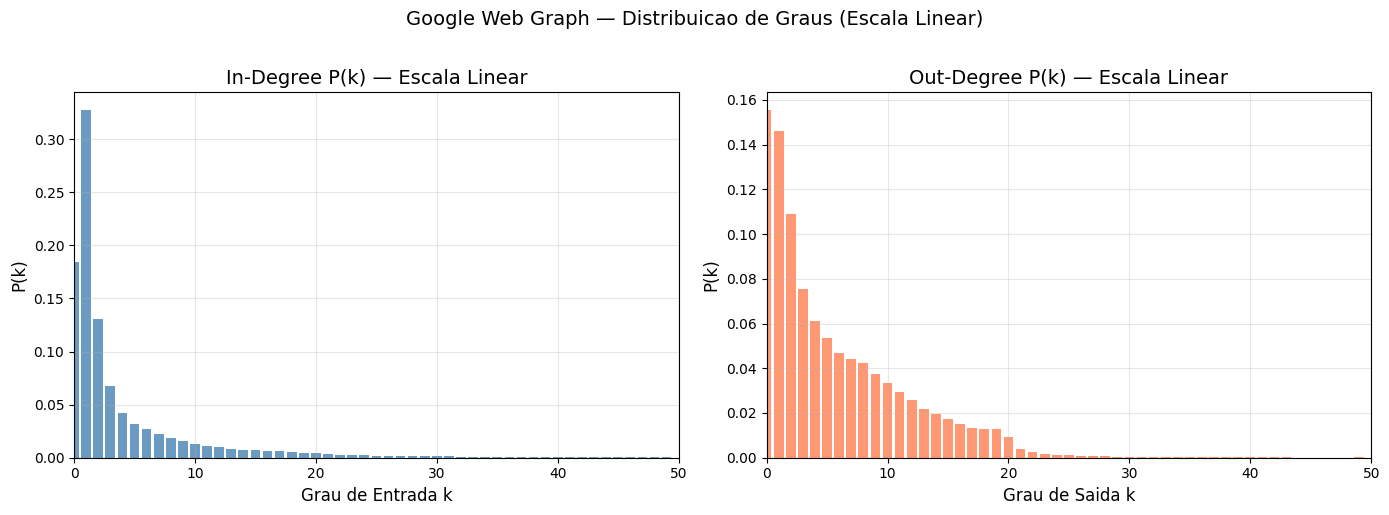

In [6]:
contagem_in  = Counter(in_degrees)
contagem_out = Counter(out_degrees)

def calcular_pk(contagem, total):
    graus = sorted(contagem.keys())
    pk    = [contagem[k] / total for k in graus]
    return np.array(graus), np.array(pk)

k_in,  pk_in  = calcular_pk(contagem_in,  V)
k_out, pk_out = calcular_pk(contagem_out, V)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(k_in[:50],  pk_in[:50],  color='steelblue', alpha=0.8, width=0.8)
axes[0].set_title('In-Degree P(k) — Escala Linear')
axes[0].set_xlabel('Grau de Entrada k'); axes[0].set_ylabel('P(k)'); axes[0].set_xlim(0, 50)
axes[1].bar(k_out[:50], pk_out[:50], color='coral', alpha=0.8, width=0.8)
axes[1].set_title('Out-Degree P(k) — Escala Linear')
axes[1].set_xlabel('Grau de Saida k');  axes[1].set_ylabel('P(k)'); axes[1].set_xlim(0, 50)
plt.suptitle('Google Web Graph — Distribuicao de Graus (Escala Linear)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribuicao_linear.png', dpi=150, bbox_inches='tight')
plt.show()

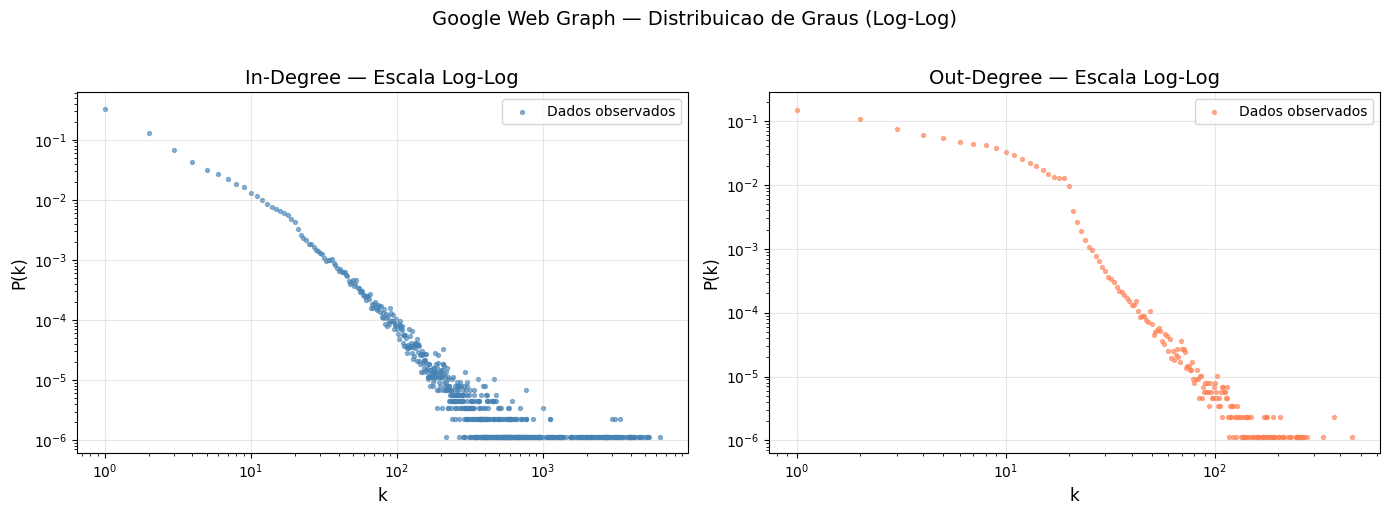

In [7]:
mask_in  = pk_in  > 0
mask_out = pk_out > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(k_in[mask_in],   pk_in[mask_in],   s=8, alpha=0.6, color='steelblue', label='Dados observados')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_title('In-Degree — Escala Log-Log')
axes[0].set_xlabel('k'); axes[0].set_ylabel('P(k)'); axes[0].legend()
axes[1].scatter(k_out[mask_out], pk_out[mask_out], s=8, alpha=0.6, color='coral', label='Dados observados')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_title('Out-Degree — Escala Log-Log')
axes[1].set_xlabel('k'); axes[1].set_ylabel('P(k)'); axes[1].legend()
plt.suptitle('Google Web Graph — Distribuicao de Graus (Log-Log)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig2_distribuicao_loglog.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parte 7 — Ajuste por Lei de Potência (MLE)

### Por que não regressão linear no log-log?
1. Introduz viés sistemático nos estimadores
2. Não trata graus com P(k) = 0
3. Não fornece teste estatístico

### Método: MLE + KS — Clauset et al. (2009)
- **MLE** — encontra o γ que maximiza a verossimilhança dos dados
- **xmin** — estimado automaticamente minimizando KS
- **KS** — distância entre curva ajustada e dados (menor = melhor)

In [8]:
print('Lei de potencia in-degree...')
in_deg_pos = [d for d in in_degrees if d > 0]
fit_in     = powerlaw.Fit(in_deg_pos, discrete=True, verbose=False)
gamma_in   = fit_in.alpha
xmin_in    = fit_in.xmin
ks_in      = fit_in.D
n_cauda_in = sum(1 for d in in_deg_pos if d >= xmin_in)
R_in, p_in = fit_in.distribution_compare('power_law', 'lognormal')

print('='*50)
print('   AJUSTE — IN-DEGREE')
print('='*50)
print(f'   Expoente gamma : {gamma_in:.4f}')
print(f'   x_min          : {xmin_in:.0f}')
print(f'   Distancia KS   : {ks_in:.6f}')
print(f'   Nos na cauda   : {n_cauda_in:,} ({n_cauda_in/len(in_deg_pos)*100:.1f}%)')
print(f'   R vs lognormal : {R_in:.4f}')
print(f'   p vs lognormal : {p_in:.4f}')
print('='*50)
print(f'\ngamma = {gamma_in:.2f} — ', end='')
print('faixa classica (2 < gamma < 3)!' if 2 < gamma_in < 3 else 'fora da faixa classica')

Lei de potencia in-degree...
   AJUSTE — IN-DEGREE
   Expoente gamma : 2.5654
   x_min          : 35
   Distancia KS   : 0.010640
   Nos na cauda   : 20,941 (2.9%)
   R vs lognormal : 0.0616
   p vs lognormal : 0.8475

gamma = 2.57 — faixa classica (2 < gamma < 3)!


In [9]:
print('Lei de potencia out-degree...')
out_deg_pos  = [d for d in out_degrees if d > 0]
fit_out      = powerlaw.Fit(out_deg_pos, discrete=True, verbose=False)
gamma_out    = fit_out.alpha
xmin_out     = fit_out.xmin
ks_out       = fit_out.D
n_cauda_out  = sum(1 for d in out_deg_pos if d >= xmin_out)
R_out, p_out = fit_out.distribution_compare('power_law', 'lognormal')

print('='*50)
print('   AJUSTE — OUT-DEGREE')
print('='*50)
print(f'   Expoente gamma : {gamma_out:.4f}')
print(f'   x_min          : {xmin_out:.0f}')
print(f'   Distancia KS   : {ks_out:.6f}')
print(f'   Nos na cauda   : {n_cauda_out:,} ({n_cauda_out/len(out_deg_pos)*100:.1f}%)')
print(f'   R vs lognormal : {R_out:.4f}')
print(f'   p vs lognormal : {p_out:.4f}')
print('='*50)
print(f'\nKS = {ks_out:.3f} — ajuste fraco (esperado, out-degree e decisao humana)')

Lei de potencia out-degree...
   AJUSTE — OUT-DEGREE
   Expoente gamma : 2.9746
   x_min          : 8
   Distancia KS   : 0.118493
   Nos na cauda   : 270,473 (36.6%)
   R vs lognormal : -23918.3095
   p vs lognormal : 0.0000

KS = 0.118 — ajuste fraco (esperado, out-degree e decisao humana)


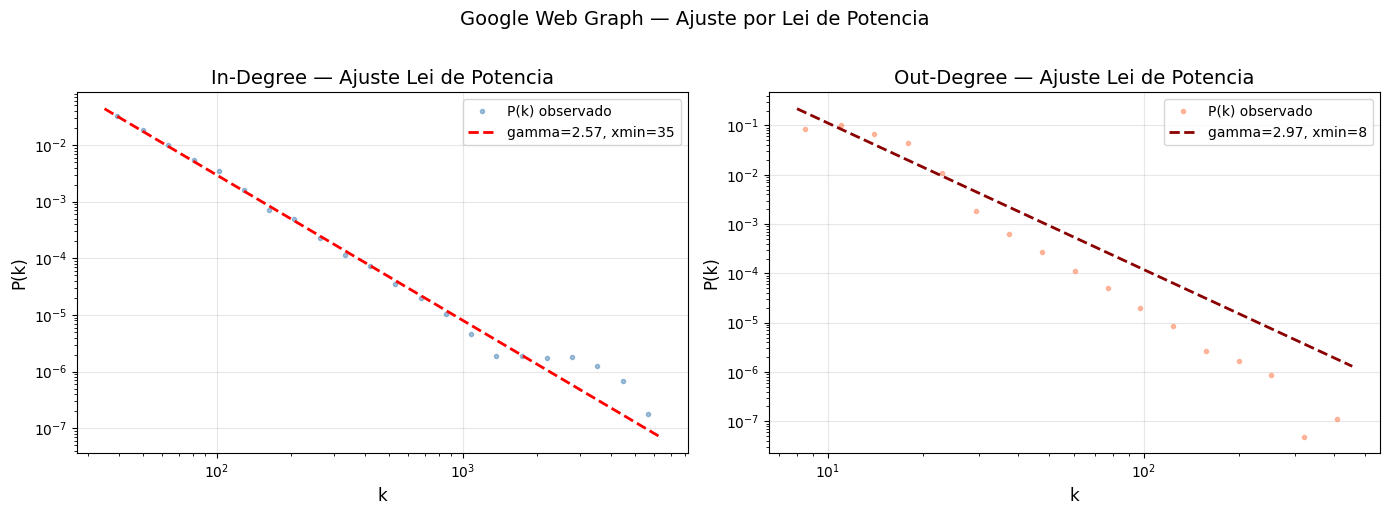

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fit_in.plot_pdf(ax=axes[0], color='steelblue', linewidth=0, marker='o', markersize=3, alpha=0.5, label='P(k) observado')
fit_in.power_law.plot_pdf(ax=axes[0], color='red', linestyle='--', linewidth=2, label=f'gamma={gamma_in:.2f}, xmin={xmin_in:.0f}')
axes[0].set_title('In-Degree — Ajuste Lei de Potencia')
axes[0].set_xlabel('k'); axes[0].set_ylabel('P(k)'); axes[0].legend()
fit_out.plot_pdf(ax=axes[1], color='coral', linewidth=0, marker='o', markersize=3, alpha=0.5, label='P(k) observado')
fit_out.power_law.plot_pdf(ax=axes[1], color='darkred', linestyle='--', linewidth=2, label=f'gamma={gamma_out:.2f}, xmin={xmin_out:.0f}')
axes[1].set_title('Out-Degree — Ajuste Lei de Potencia')
axes[1].set_xlabel('k'); axes[1].set_ylabel('P(k)'); axes[1].legend()
plt.suptitle('Google Web Graph — Ajuste por Lei de Potencia', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig3_ajuste_lei_potencia.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parte 8 — Tabela Resumo

In [11]:
print('='*60)
print('        RESUMO — GOOGLE WEB GRAPH')
print('='*60)
print(f'  Estrutura      : Digraph com Bag (Algs 4)')
print(f'  Vertices |V|   : {V:>15,}')
print(f'  Arestas  |E|   : {E:>15,}')
print(f'  Densidade      : {densidade:>15.2e}')
print(f'  Grau medio out : {grau_medio_out:>15.4f}')
print(f'  Grau medio in  : {grau_medio_in:>15.4f}')
print(f'  Clustering*    : {clustering_medio:>15.6f}  (* n={TAMANHO_AMOSTRA:,})')
print(f'  gamma in-degree: {gamma_in:>15.4f}')
print(f'  KS in-degree   : {ks_in:>15.6f}')
print(f'  gamma out-deg  : {gamma_out:>15.4f}')
print(f'  KS out-degree  : {ks_out:>15.6f}')
print('='*60)

        RESUMO — GOOGLE WEB GRAPH
  Estrutura      : Digraph com Bag (Algs 4)
  Vertices |V|   :         875,713
  Arestas  |E|   :       5,105,039
  Densidade      :        6.66e-06
  Grau medio out :          5.8296
  Grau medio in  :          5.8296
  Clustering*    :        0.272519  (* n=3,000)
  gamma in-degree:          2.5654
  KS in-degree   :        0.010640
  gamma out-deg  :          2.9746
  KS out-degree  :        0.118493


---
## Parte 9 — Discussão: A rede é de escala livre?

### Evidências a favor
1. **In-degree segue lei de potência:** γ ≈ 2.57, KS ≈ 0.011 — ajuste excelente.
2. **γ na faixa clássica:** 2 < γ < 3 (Barabási & Albert, 1999).
3. **Hubs presentes:** grau máximo de entrada muito acima da média.
4. **Mecanismo:** a web cresce por *preferential attachment* — base do modelo BA.

### Limitações
1. **Out-degree com ajuste fraco** — editores decidem quantos links publicam.
2. **Lei válida apenas para k ≥ xmin** — descreve só a cauda.
3. **Clustering moderado-alto** — mais alto que o modelo BA puro.

### Conclusão

> O Google Web Graph **é de escala livre no in-degree**: γ na faixa clássica, KS excelente, hubs confirmados. O out-degree não segue lei de potência robustamente — comportamento esperado pois é uma decisão humana. Classificação: ***scale-free like***.

---
## Referências

1. **Estrutura de dados:** Sedgewick, R., & Wayne, K. (2011). *Algorithms, 4th Edition*. Addison-Wesley. (Capítulo 4 — Directed Graphs)
2. **Material de apoio:** AVA Unifor — Resolução de Problemas em Grafos.